# MMLU-Pro MCQA Dataset: 700 Examples Across 14 Subjects

This notebook demonstrates the **MMLU-Pro dataset artifact** prepared for the Arrhenius inference-energy experiment.

**Source**: TIGER-Lab/MMLU-Pro (HuggingFace, MIT license, NeurIPS 2024) — 12,032 test-split rows downloaded.  
**Output**: 700 unique MCQA examples across 14 subjects, formatted for LLM inference experiments.  
**Schema**: Each example has an `input` (formatted prompt), `output` (correct answer letter A–J), and rich metadata including subject, split, and wrong-answer fields for computing Δ = logit(wrong) − logit(correct).

The demo loads a curated 42-example subset (3 examples per subject) from GitHub.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# Core packages — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Imports

Standard imports from the original `data.py` script, plus `pandas` and `matplotlib` for the demo visualization.

In [2]:
import json
import sys
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from loguru import logger

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Data Loading

Load `mini_demo_data.json` from GitHub (falls back to local file when running locally).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-ce2af9-arrhenius-kinetics-of-llm-inference-acti/main/round-1/dataset-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
import os  # needed by load_data fallback

In [5]:
data = load_data()
logger.info(f"Loaded data with {len(data['datasets'][0]['examples'])} examples")

19:57:42|INFO   |Loaded data with 42 examples


## Configuration

Tunable parameters for the demo. The original script processes all 700 examples; here we start with a minimal subset.

In [6]:
# --- Config ---
N_EXAMPLES_DISPLAY = 5      # How many examples to print in detail (original: all 700)
LETTERS = "ABCDEFGHIJ"      # Answer letters supported by the schema

## Dataset Metadata

Inspect the dataset metadata: source, filters applied, subjects covered, and seed used for stratified sampling.

In [7]:
meta = data["metadata"]
logger.info(f"Source: {meta['source']}")
logger.info(f"Total filtered: {meta['total_filtered']} | Seed: {meta['seed']} | Schema: {meta['schema_version']}")
logger.info(f"Subjects ({len(meta['subjects'])}): {meta['subjects']}")
logger.info(f"Filter counts: {meta['filter_counts']}")

19:57:42|INFO   |Source: TIGER-Lab/MMLU-Pro


19:57:42|INFO   |Total filtered: 12032 | Seed: 42 | Schema: 1.0


19:57:42|INFO   |Subjects (14): ['biology', 'business', 'chemistry', 'computer science', 'economics', 'engineering', 'health', 'history', 'law', 'math', 'other', 'philosophy', 'physics', 'psychology']


19:57:42|INFO   |Filter counts: {'raw': 12032, 'after_F1': 12032, 'after_F2': 12032, 'after_F3': 12032, 'after_F4': 12032}


## Core Conversion Functions

These are the two key functions from `data.py` — unchanged from the original script.

- `format_mcqa_input`: formats question + choices as a lettered prompt string (A. ... B. ...)
- `row_to_example`: converts a raw MMLU-Pro row into the `exp_sel_data_out` schema

In [8]:
def format_mcqa_input(question_text: str, choices: list) -> str:
    """Format question + choices as a MCQA prompt string."""
    lines = [question_text.strip(), ""]
    for i, c in enumerate(choices):
        lines.append(f"{LETTERS[i]}. {c}")
    return "\n".join(lines)


def row_to_example(row: dict) -> dict:
    """Convert a data_out.json row to an exp_sel_data_out example."""
    input_str = format_mcqa_input(row["question_text"], row["choices"])
    output_str = row["correct_answer_letter"]
    return {
        "input": input_str,
        "output": output_str,
        "metadata_question_id": row["question_id"],
        "metadata_subject": row["subject"],
        "metadata_num_choices": row["num_choices"],
        "metadata_correct_answer_index": row["correct_answer_index"],
        "metadata_correct_answer_text": row["correct_answer_text"],
        "metadata_wrong_answer_letter": row["wrong_answer_letter"],
        "metadata_wrong_answer_index": row["wrong_answer_index"],
        "metadata_wrong_answer_text": row["wrong_answer_text"],
        "metadata_split": row["split"],
        "metadata_src": row.get("src", ""),
        "metadata_task_type": "multiple_choice_qa",
    }

## Inspect Examples

The mini demo data is already in the `exp_sel_data_out` schema (pre-converted). Here we inspect the first few examples to verify the format — showing the `input` prompt, `output` answer letter, and key metadata fields.

In [9]:
examples = data["datasets"][0]["examples"]
logger.info(f"Total examples in demo: {len(examples)}")

for i, ex in enumerate(examples[:N_EXAMPLES_DISPLAY]):
    print(f"\n--- Example {i+1} ---")
    print(f"Subject   : {ex['metadata_subject']}")
    print(f"Split     : {ex['metadata_split']}")
    print(f"# Choices : {ex['metadata_num_choices']}")
    print(f"Output    : {ex['output']} (correct answer)")
    print(f"Wrong ans : {ex['metadata_wrong_answer_letter']} — {ex['metadata_wrong_answer_text'][:60]}")
    print(f"Input (first 200 chars):\n{ex['input'][:200]}...")

19:57:42|INFO   |Total examples in demo: 42



--- Example 1 ---
Subject   : biology
Split     : pilot_set
# Choices : 10
Output    : D (correct answer)
Wrong ans : A — Earth is millions of years old, and populations are unchangi
Input (first 200 chars):
What was the prevailing notion prior to the time of Lyell and Darwin?

A. Earth is millions of years old, and populations are unchanging.
B. Earth is millions of years old, and populations gradually c...

--- Example 2 ---
Subject   : biology
Split     : main_set
# Choices : 10
Output    : E (correct answer)
Wrong ans : A — Emergence of the first flowering plants, the appearance of f
Input (first 200 chars):
Explain the four important evolutionary events that occurred inthe Paleozoic Era.

A. Emergence of the first flowering plants, the appearance of first large mammals, the rise of marine reptiles, and t...

--- Example 3 ---
Subject   : biology
Split     : catalysis_set
# Choices : 10
Output    : I (correct answer)
Wrong ans : A — Telophase
Input (first 200 chars):
During which 

## Deduplication Logic

The original script collects examples from three splits (pilot_set, main_set, catalysis_set) and deduplicates by `question_id`. The catalysis_set is a subset of main_set, so deduplication yields 700 unique examples in the full dataset.

In [10]:
# In the full pipeline, data is collected from three splits with deduplication:
#   for split_key in ("pilot_set", "main_set", "catalysis_set"):
#       for row in data[split_key]:
#           if row["question_id"] not in seen_ids:
#               seen_ids.add(row["question_id"])
#               all_rows.append(row)

# For the demo, we verify deduplication on the mini subset:
seen_ids = set()
unique_examples = []
for ex in examples:
    qid = ex["metadata_question_id"]
    if qid not in seen_ids:
        seen_ids.add(qid)
        unique_examples.append(ex)

logger.info(f"After dedup: {len(unique_examples)} unique examples (from {len(examples)} total)")

19:57:42|INFO   |After dedup: 42 unique examples (from 42 total)


## Split & Subject Distribution

The full dataset has three splits:
- **pilot_set** (200): for initial calibration runs
- **main_set** (500): for the primary Arrhenius experiment (stratified across 14 subjects)
- **catalysis_set** (50): a subset of main_set for quick catalysis experiments

Here we compute split and subject counts from the demo subset.

In [11]:
splits = Counter(ex["metadata_split"] for ex in unique_examples)
subjects = Counter(ex["metadata_subject"] for ex in unique_examples)

logger.info(f"Split counts: {dict(splits)}")
logger.info(f"Subject counts: {dict(subjects)}")

19:57:42|INFO   |Split counts: {'pilot_set': 14, 'main_set': 14, 'catalysis_set': 14}


19:57:42|INFO   |Subject counts: {'biology': 3, 'business': 3, 'chemistry': 3, 'computer science': 3, 'economics': 3, 'engineering': 3, 'health': 3, 'history': 3, 'law': 3, 'math': 3, 'other': 3, 'philosophy': 3, 'physics': 3, 'psychology': 3}


## Visualization: Subject & Split Distribution

Bar charts showing the distribution of examples across 14 subjects and 3 splits in the demo subset.

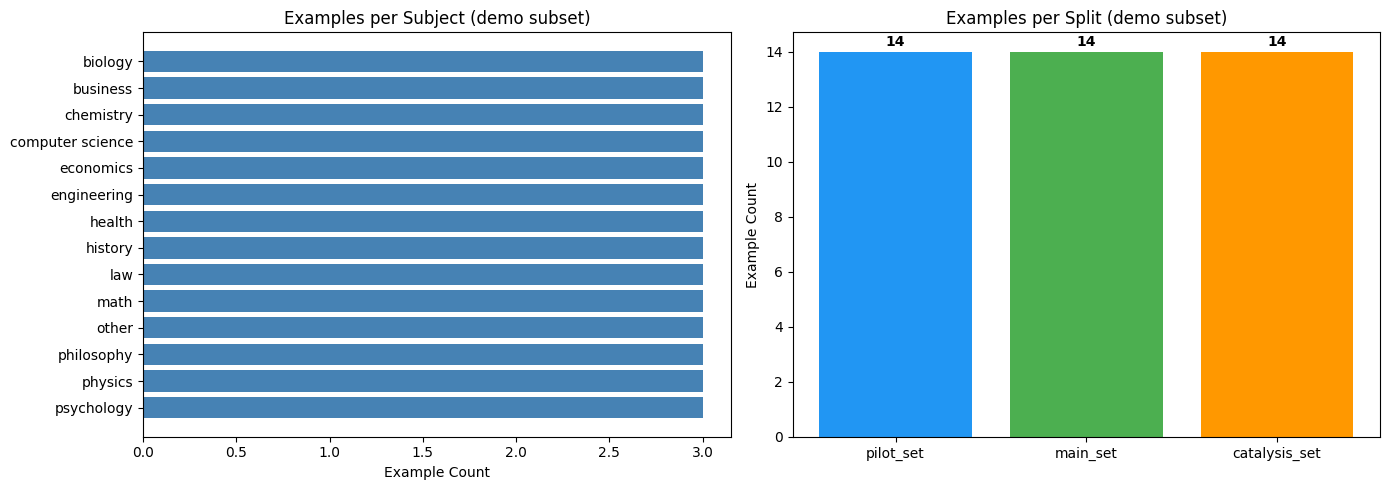

Figure saved: subject_split_distribution.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subject distribution
subj_sorted = sorted(subjects.items(), key=lambda x: -x[1])
subj_labels, subj_counts = zip(*subj_sorted)
axes[0].barh(subj_labels, subj_counts, color='steelblue')
axes[0].set_xlabel('Example Count')
axes[0].set_title('Examples per Subject (demo subset)')
axes[0].invert_yaxis()

# Split distribution
split_labels = list(splits.keys())
split_counts = list(splits.values())
axes[1].bar(split_labels, split_counts, color=['#2196F3', '#4CAF50', '#FF9800'])
axes[1].set_ylabel('Example Count')
axes[1].set_title('Examples per Split (demo subset)')
for i, v in enumerate(split_counts):
    axes[1].text(i, v + 0.1, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('subject_split_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Figure saved: subject_split_distribution.png")

## Summary Table

Key statistics about the dataset in a readable table format.

In [13]:
# Build summary dataframe
rows = []
for ex in unique_examples:
    rows.append({
        'subject': ex['metadata_subject'],
        'split': ex['metadata_split'],
        'num_choices': ex['metadata_num_choices'],
        'output': ex['output'],
        'wrong_letter': ex['metadata_wrong_answer_letter'],
        'question_id': ex['metadata_question_id'],
    })

df = pd.DataFrame(rows)
print(f"Total unique examples: {len(df)}")
print(f"Subjects covered: {df['subject'].nunique()}")
print(f"Avg choices per example: {df['num_choices'].mean():.1f}")
print(f"Answer distribution:\n{df['output'].value_counts().head(10).to_string()}")
print()
print("Subject × Split crosstab:")
print(pd.crosstab(df['subject'], df['split']))

Total unique examples: 42
Subjects covered: 14
Avg choices per example: 9.5
Answer distribution:
output
C    6
G    6
B    6
H    6
I    5
D    5
F    4
A    2
E    1
J    1

Subject × Split crosstab:
split             catalysis_set  main_set  pilot_set
subject                                             
biology                       1         1          1
business                      1         1          1
chemistry                     1         1          1
computer science              1         1          1
economics                     1         1          1
engineering                   1         1          1
health                        1         1          1
history                       1         1          1
law                           1         1          1
math                          1         1          1
other                         1         1          1
philosophy                    1         1          1
physics                       1         1          1
psyc